# 4 · The Bayes filter and grid localisation

**Recap** ([theory](https://github.com/Rudip1/learn-state-estimation/blob/main/1_theory/04_bayes_filter.md)).
Under the Markov and conditional-independence assumptions the belief obeys
$\overline{\text{bel}}(x_k) = \int p(x_k\mid x_{k-1},u_k)\,\text{bel}(x_{k-1})\,dx_{k-1}$ (prediction: spread) and
$\text{bel}(x_k) = \eta\,p(z_k\mid x_k)\,\overline{\text{bel}}(x_k)$ (correction: sharpen). On a finite state set this
is a matrix–vector product followed by an element-wise product. Grid localisation applies it to cells of
$(x, y, \theta)$: shift and blur for motion, log-likelihoods with the cell size folded into $R$ for measurements. A
grid can hold multimodal beliefs, start from a uniform belief (global localisation) and, mixed with a little uniform
probability, recover from kidnapping.

In [1]:
# Installs the module when it is not available yet (e.g. on Colab). Building the C++ takes a few minutes.
try:
    import state_estimation
except ImportError:
    %pip install -q git+https://github.com/Rudip1/learn-state-estimation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import state_estimation as se
from state_estimation import plotting

plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (6, 4.5)})

## A corridor with three doors

Ten cyclic cells, doors at 1, 4 and 8. The detector reports "door" with probability 0.8 at a door and 0.1 at a wall.
The robot reads *door*, moves 3 cells, reads *door*, moves 3 cells, reads *wall* (§4.2).

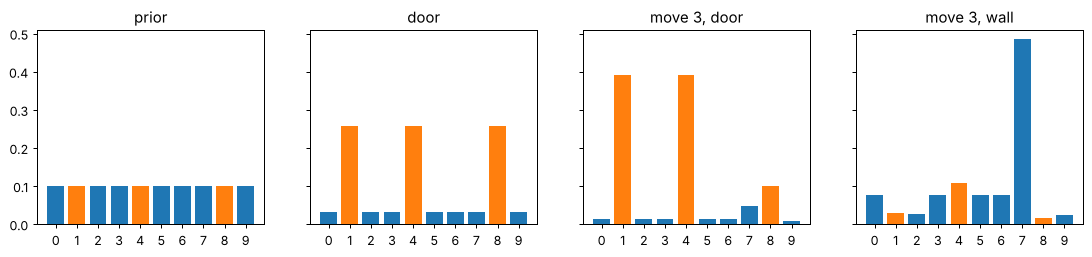

after step 1: [0.0323 0.2581 0.0323 0.0323 0.2581 0.0323 0.0323 0.0323 0.2581 0.0323] 
after step 2: [0.0126 0.3902 0.0126 0.0126 0.3902 0.0126 0.0126 0.0488 0.1005 0.0074] 
after step 3: [0.0775 0.0295 0.0265 0.0767 0.1077 0.0775 0.0775 0.4848 0.0172 0.0249]


In [3]:
doors = {1, 4, 8}
def likelihood(saw_door):
    return np.array([(0.8 if i in doors else 0.1) if saw_door else (0.2 if i in doors else 0.9) for i in range(10)])
kernel = np.array([0.1, 0.8, 0.1])          # move 2, 3 or 4 cells

f = se.DiscreteBayesFilter(np.ones(10))
history = [f.belief.copy()]
for step, reading in enumerate([True, True, False]):
    if step > 0:
        f.predict_cyclic(kernel, 2)
    f.update(likelihood(reading))
    history.append(f.belief.copy())

fig, axes = plt.subplots(1, 4, figsize=(15, 2.8), sharey=True)
for ax, b, title in zip(axes, history, ["prior", "door", "move 3, door", "move 3, wall"]):
    ax.bar(range(10), b, color=["C1" if i in doors else "C0" for i in range(10)])
    ax.set_title(title); ax.set_xticks(range(10))
plt.show()
print("after step 1:", history[1].round(4), "\nafter step 2:", history[2].round(4), "\nafter step 3:", history[3].round(4))

### ✏️ Exercise 1 — the discrete Bayes filter in NumPy

Implement `predict_np(belief, kernel, offset)` (cyclic: the robot moves by `offset + i` cells with probability
`kernel[i]`; `np.roll` helps) and `update_np(belief, likelihood)` (eq. 4.7). Reproduce the three steps above.

In [4]:
def predict_np(belief, kernel, offset):
    ### BEGIN SOLUTION
    out = np.zeros_like(belief)
    for i, p in enumerate(kernel):
        out += p * np.roll(belief, offset + i)
    return out
    ### END SOLUTION

def update_np(belief, likelihood):
    ### BEGIN SOLUTION
    b = belief * likelihood
    return b / b.sum()
    ### END SOLUTION

In [5]:
b = np.ones(10) / 10
b = update_np(b, likelihood(True));  assert np.allclose(b, history[1])
b = update_np(predict_np(b, kernel, 2), likelihood(True));  assert np.allclose(b, history[2])
b = update_np(predict_np(b, kernel, 2), likelihood(False)); assert np.allclose(b, history[3])
print("✔ matches; most likely cell:", int(np.argmax(b)), f"with {b.max():.4f}")

✔ matches; most likely cell: 7 with 0.4848


## Grid localisation of a planar pose

Six indistinguishable landmarks, a sensor with 4 m range, odometry from noisy encoders. The grid starts uniform:
the robot does not know where it is.

cells in this grid: 86400 | a 10 m x 10 m map at 0.25 m and 36 headings: 57600


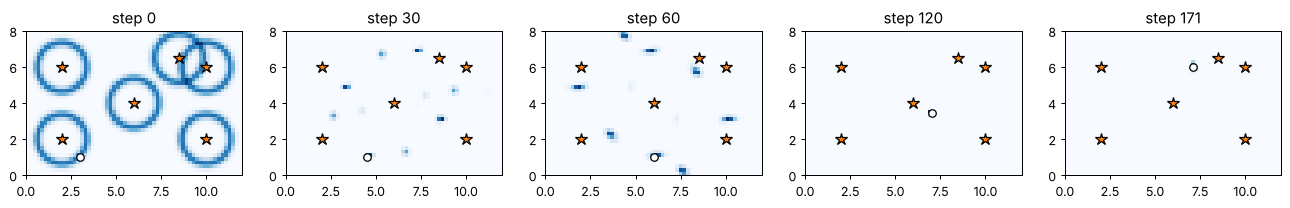

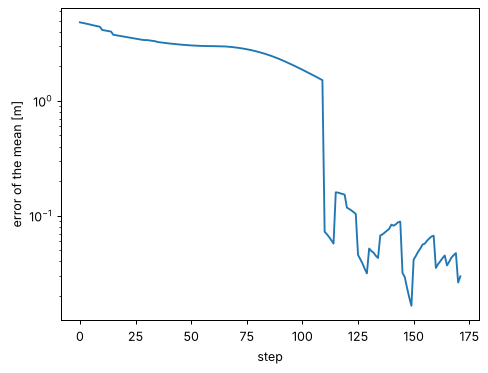

final estimate [7.105 5.998 1.479]  truth [7.083 5.978 1.55 ]


In [6]:
landmarks = np.array([[2.0, 2.0], [2.0, 6.0], [10.0, 2.0], [10.0, 6.0], [6.0, 4.0], [8.5, 6.5]])
dd, dt, k = se.DifferentialDrive(0.1, 0.5), 0.1, 1e-4
u = np.vstack([np.tile([0.5, 0.0], (60, 1)), np.tile([0.5, 0.5], (31, 1)), np.tile([0.5, 0.0], (80, 1))])
x0 = np.array([3.0, 1.0, 0.0])
truth = se.integrate_controls(x0, u, dt)
odom = se.run_dead_reckoning(x0, np.zeros((3, 3)), se.simulate_wheel_travel(u, dt, dd, k, se.Rng(1)), dd, k).poses
sensor = se.RangeBearingSensor(max_range=4.0, fov=2 * np.pi, sigma_range=0.1, sigma_bearing=0.05)
alpha = [0.02, 0.002, 0.02, 0.002]
spec = se.GridSpec(0, 12, 0, 8, 0.2, 36)
print("cells in this grid:", se.GridLocalization(spec).size,
      "| a 10 m x 10 m map at 0.25 m and 36 headings:", se.GridLocalization(se.GridSpec(0, 10, 0, 10, 0.25, 36)).size)

def run_grid(spec, known=False, every=5, inflate=True, kidnap_at=None, eps=0.0, seed=2):
    grid = se.GridLocalization(spec)
    rng = se.Rng(seed)
    errors, sigmas, snaps = [], [], {}
    for kk in range(len(u) + 1):
        if kk > 0:
            grid.predict_odometry(odom[kk - 1], odom[kk], alpha)
        x_true = truth[kk] if kidnap_at is None or kk < kidnap_at else truth[kk] + np.array([-4.0, 0.0, 0.0])
        if kk % every == 0:
            obs = sensor.observe(x_true, landmarks, rng)
            if known:
                grid.update_range_bearing(obs, landmarks, sensor.R(), inflate)
            else:
                grid.update_range_bearing_anonymous(obs, landmarks, sensor.R(), inflate)
        if eps > 0:
            grid.mix_uniform(eps)
        errors.append(np.linalg.norm(grid.mean()[:2] - x_true[:2]))
        sigmas.append(np.sqrt(np.trace(grid.covariance()[:2, :2])))
        if kk in (0, 30, 60, 120, len(u)):
            snaps[kk] = grid.marginal_xy()
    return np.array(errors), snaps, grid, np.array(sigmas)

errors, snaps, grid, _ = run_grid(spec)
fig, axes = plt.subplots(1, 5, figsize=(18, 3.2))
for ax, (kk, m) in zip(axes, snaps.items()):
    ax.imshow(m ** 0.5, origin="lower", extent=(0, 12, 0, 8), cmap="Blues")
    ax.plot(landmarks[:, 0], landmarks[:, 1], "*", color="C1", ms=10, mec="k")
    ax.plot(*truth[kk, :2], "o", color="w", mec="k"); ax.set_title(f"step {kk}")
plt.show()
plt.plot(errors); plt.xlabel("step"); plt.ylabel("error of the mean [m]"); plt.yscale("log"); plt.show()
print("final estimate", grid.mean().round(3), " truth", truth[-1].round(3))

### ✏️ Exercise 2 — averaging angles

The heading of the grid mean is a **circular** mean: $\bar\theta = \operatorname{atan2}(\sum_i w_i\sin\theta_i,
\sum_i w_i\cos\theta_i)$. Implement it and compare with the naive weighted average for headings spread around
$\pm\pi$.

In [7]:
def circular_mean(angles, weights):
    ### BEGIN SOLUTION
    return np.arctan2(np.sum(weights * np.sin(angles)), np.sum(weights * np.cos(angles)))
    ### END SOLUTION

In [8]:
angles = np.array([3.1, -3.1, 3.0, -3.05]); w = np.array([0.3, 0.3, 0.2, 0.2])
print(f"circular mean {circular_mean(angles, w):+.3f} rad, naive mean {np.sum(w * angles):+.3f} rad")
assert abs(abs(circular_mean(angles, w)) - np.pi) < 0.1
g = se.GridLocalization(se.GridSpec(0, 2, 0, 2, 0.5, 36))
g.set_gaussian(np.array([1.0, 1.0, np.pi - 0.05]), np.diag([0.1, 0.1, 0.2]))
th = np.array([g.cell_center(0, 0, it)[2] for it in range(36)])
w_theta = g.belief.reshape(36, -1).sum(axis=1)
assert np.isclose(circular_mean(th, w_theta), g.mean()[2])
print("✔ matches the grid's mean heading")

circular mean +3.132 rad, naive mean -0.010 rad
✔ matches the grid's mean heading


### ✏️ Exercise 3 — what landmark identities are worth

Run the same experiment with known correspondences (`known=True`) and count, for both runs, the first step after
which the error stays below 0.3 m. Identities remove the symmetric hypotheses, so they should never be slower.

In [9]:
def settle_step(errors, tol=0.3):
    ### BEGIN SOLUTION
    bad = np.nonzero(errors >= tol)[0]
    return 0 if len(bad) == 0 else int(bad[-1] + 1)
    ### END SOLUTION

In [10]:
err_known, _, _, _ = run_grid(spec, known=True)
s_anon, s_known = settle_step(errors), settle_step(err_known)
print(f"settled after step {s_anon} (indistinguishable) vs {s_known} (known identities)")
assert s_known <= s_anon

settled after step 110 (indistinguishable) vs 10 (known identities)


## 🔨 Break it — a sharp sensor on a coarse grid

Make the sensor ten times sharper and the grid twice as coarse, and switch off the cell-size term of eq. (4.10).
The likelihood evaluated at the cell centres becomes so peaked that the whole belief collapses onto one cell: the
filter reports a spread of almost zero while its error is the distance to that cell's centre — it is
**over-confident**. With the term, the reported spread matches the error. (Between scans both beliefs widen again:
on a coarse grid the trilinear splitting of sub-cell motions diffuses probability, an artefact of the grid.)

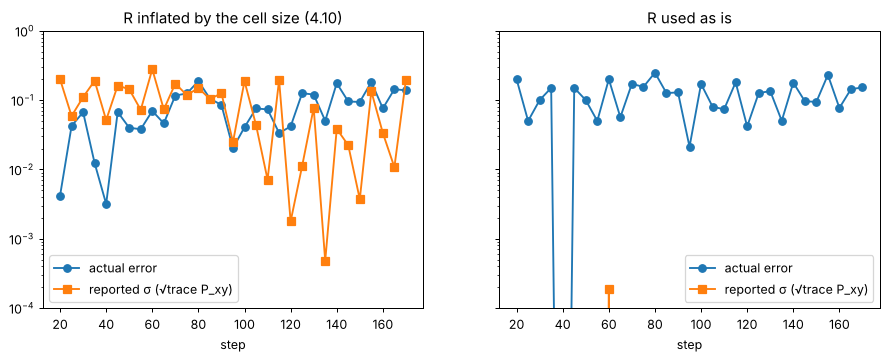

with    the cell-size term: median error 0.074 m, median reported σ 0.0774 m (after each scan)
without the cell-size term: median error 0.126 m, median reported σ 0.0000 m (after each scan)


In [11]:
sharp = se.RangeBearingSensor(max_range=4.0, fov=2 * np.pi, sigma_range=0.01, sigma_bearing=0.005)
coarse = se.GridSpec(0, 12, 0, 8, 0.4, 24)
saved = sensor
sensor = sharp
e_on, _, _, s_on = run_grid(coarse, known=True, inflate=True)
e_off, _, _, s_off = run_grid(coarse, known=True, inflate=False)
sensor = saved
scan = np.arange(20, len(e_on), 5)          # steps right after a scan
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, e, sg, title in ((axes[0], e_on, s_on, "R inflated by the cell size (4.10)"), (axes[1], e_off, s_off, "R used as is")):
    ax.plot(scan, e[scan], "o-", label="actual error"); ax.plot(scan, sg[scan], "s-", label="reported σ (√trace P_xy)")
    ax.set_yscale("log"); ax.set_ylim(1e-4, 1); ax.set_title(title); ax.set_xlabel("step"); ax.legend()
plt.show()
for name, e, sg in (("with", e_on, s_on), ("without", e_off, s_off)):
    print(f"{name:7s} the cell-size term: median error {np.median(e[scan]):.3f} m, "
          f"median reported σ {np.median(sg[scan]):.4f} m (after each scan)")

## 🔨 Break it — the kidnapped robot

At step 100 the robot is carried 4 m west. The pure filter has (numerically) zero probability there; it can only
"crawl" towards the truth as fast as the motion update spreads probability into neighbouring cells — one cell per
step here — while every scan drags it along. Mixing in $\varepsilon = 10^{-3}$ of uniform probability per step
(eq. 4.12) keeps every cell alive, and the first scan after the kidnapping finds the robot.

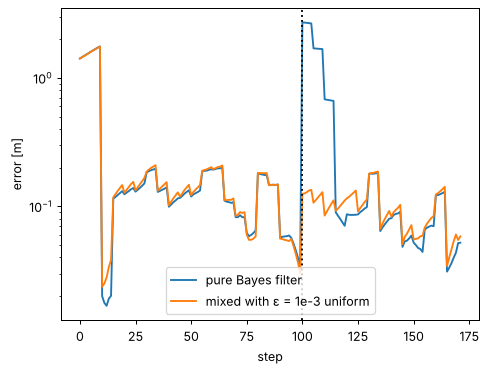

steps to get below 0.3 m after the kidnapping: 15 (pure) vs 0 (mixed)


In [12]:
e_pure, _, _, _ = run_grid(spec, known=True, kidnap_at=100)
e_mix, _, _, _ = run_grid(spec, known=True, kidnap_at=100, eps=1e-3)
plt.plot(e_pure, label="pure Bayes filter"); plt.plot(e_mix, label="mixed with ε = 1e-3 uniform")
plt.axvline(100, color="k", ls=":"); plt.yscale("log"); plt.xlabel("step"); plt.ylabel("error [m]"); plt.legend()
plt.show()
print(f"steps to get below 0.3 m after the kidnapping: {settle_step(e_pure[100:])} (pure) vs "
      f"{settle_step(e_mix[100:])} (mixed)")

## What to remember

- Prediction is a convolution with the motion model, correction a product with the likelihood; normalise.
- A grid represents any belief — multimodal, uniform — at a cost linear in the number of cells, which grows
  exponentially with the state dimension.
- Account for the cell size when the sensor is sharper than the grid, and work in log-likelihoods.
- Indistinguishable landmarks make the belief multimodal; identities or motion resolve it.
- A filter that is certain cannot recover from kidnapping unless every hypothesis keeps some probability.